# CANSAT Duck2Dragon — Data Analysis

Reads `log.txt` from ground station serial logger (`read_serial.py`).

## CSV fields (23)
| # | Field | Unit | Source |
|---|-------|------|--------|
| 0 | millis | ms | ESP32 |
| 1 | lat | deg | GPS |
| 2 | lon | deg | GPS |
| 3 | alt_gps | m | GPS |
| 4 | sats | count | GPS |
| 5 | alt_baro | m | MS5611 |
| 6 | temp | °C | MS5611 |
| 7 | pressure | hPa | MS5611 |
| 8 | ax | m/s² | BNO085 linear accel |
| 9 | ay | m/s² | BNO085 linear accel |
| 10 | az | m/s² | BNO085 linear accel |
| 11 | gx | rad/s | BNO085 gyro |
| 12 | gy | rad/s | BNO085 gyro |
| 13 | gz | rad/s | BNO085 gyro |
| 14 | qw | — | BNO085 quaternion |
| 15 | qx | — | BNO085 quaternion |
| 16 | qy | — | BNO085 quaternion |
| 17 | qz | — | BNO085 quaternion |
| 18 | high_ax | g | ADXL375 |
| 19 | high_ay | g | ADXL375 |
| 20 | high_az | g | ADXL375 |
| 21 | voltage | V | INA219 |
| 22 | current | mA | INA219 |

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

LOG_PATH = Path('log_vibration_test3.txt')

COLUMNS = [
    'millis','lat','lon','alt_gps','sats',
    'alt_baro','temp','pressure',
    'ax','ay','az',
    'gx','gy','gz',
    'qw','qx','qy','qz',
    'high_ax','high_ay','high_az',
    'voltage','current'
]

rows = []
with open(LOG_PATH) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        parts = line.split(',')
        # Accept 23 or 24 fields (24 = trailing comma)
        if len(parts) >= 23:
            rows.append(parts[:23])  # Take first 23 fields

df = pd.DataFrame(rows, columns=COLUMNS)
df = df.apply(pd.to_numeric, errors='coerce')
df['time_s'] = df['millis'] / 1000.0

print(f'Loaded {len(df)} rows')
df.head()

Loaded 160 rows


,millis,lat,lon,alt_gps,sats,alt_baro,temp,pressure,ax,ay,...,qw,qx,qy,qz,high_ax,high_ay,high_az,voltage,current,time_s
0,1618633,8.367500,100.043922,-1.8,12,43.30,30.22,1008.06,0.0000,0.0000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.164,NaN,1618.633
1,1619503,8.367500,100.043922,-1.8,12,43.63,30.22,1008.02,0.0000,0.0000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.160,NaN,1619.503
2,1620355,8.367500,100.043922,-1.8,12,43.97,30.22,1007.98,0.5156,-0.8555,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.164,NaN,1620.355
3,1621225,8.367499,100.043922,-3.4,12,43.47,30.22,1008.04,0.0078,1.5117,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.160,NaN,1621.225
4,1622078,8.367499,100.043922,-3.4,12,43.30,30.22,1008.06,-2.0664,2.3164,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.164,NaN,1622.078


In [38]:
# Summary statistics
df.describe().round(3)

,millis,lat,lon,alt_gps,sats,alt_baro,temp,pressure,ax,ay,...,qw,qx,qy,qz,high_ax,high_ay,high_az,voltage,current,time_s
count,160.000,160.000,159.000,160.000,160.000,160.000,160.000,160.000,160.000,159.000,...,160.000,160.000,160.000,160.000,160.0,160.0,160.0,160.000,0.0,160.000
mean,1504405.462,7.740,92.493,-6.608,11.531,43.972,29.781,1007.980,-0.202,1.009,...,0.995,-0.000,0.000,0.006,0.0,0.0,0.0,3.141,NaN,1504.405
std,520137.816,2.211,26.510,4.083,5.666,0.394,0.254,0.047,8.420,8.627,...,0.059,0.001,0.001,0.077,0.0,0.0,0.0,0.020,NaN,520.138
min,758.000,0.000,0.000,-12.100,0.000,42.970,29.280,1007.840,-20.879,-24.039,...,0.249,-0.018,0.000,0.000,0.0,0.0,0.0,3.092,NaN,0.758
25%,1638372.000,8.368,100.044,-10.300,12.000,43.630,29.568,1007.940,0.000,0.000,...,1.000,0.000,0.000,0.000,0.0,0.0,0.0,3.124,NaN,1638.372
50%,1676314.500,8.368,100.044,-6.500,12.000,43.970,29.770,1007.980,0.000,0.000,...,1.000,0.000,0.000,0.000,0.0,0.0,0.0,3.144,NaN,1676.314
75%,1711064.500,8.368,100.044,-4.275,12.000,44.300,29.980,1008.020,0.810,2.908,...,1.000,0.000,0.000,0.000,0.0,0.0,0.0,3.156,NaN,1711.064
max,1745668.000,8.368,100.044,5.100,72.000,45.140,30.220,1008.100,23.590,23.371,...,1.000,0.000,0.013,0.968,0.0,0.0,0.0,3.180,NaN,1745.668


In [39]:
# Data quality check
print('NaN count per column:')
print(df.isna().sum())
print(f'\nGPS fix rows (sats > 0): {(df.sats > 0).sum()} / {len(df)}')
print(f'Baro valid rows (alt_baro != 0): {(df.alt_baro != 0).sum()} / {len(df)}')
print(f'Duration: {df.time_s.max():.1f} s')
print(f'Sample rate: {len(df)/df.time_s.max():.2f} Hz')

NaN count per column:
millis        0
lat           0
lon           1
alt_gps       0
sats          0
alt_baro      0
temp          0
pressure      0
ax            0
ay            1
az            0
gx            0
gy            0
gz            0
qw            0
qx            0
qy            0
qz            0
high_ax       0
high_ay       0
high_az       0
voltage       0
current     160
time_s        0
dtype: int64

GPS fix rows (sats > 0): 151 / 160
Baro valid rows (alt_baro != 0): 160 / 160
Duration: 1745.7 s
Sample rate: 0.09 Hz


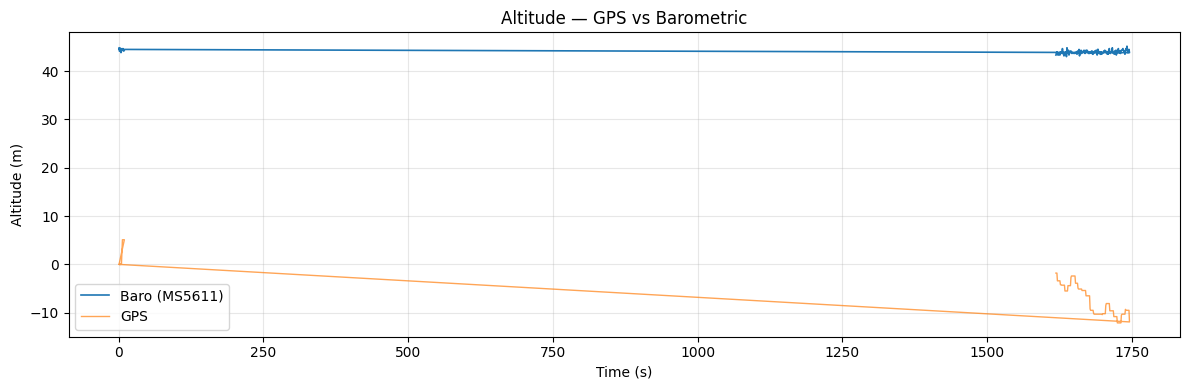

In [40]:
# Altitude: GPS vs Barometric
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.time_s, df.alt_baro, label='Baro (MS5611)', linewidth=1.2)
ax.plot(df.time_s, df.alt_gps,  label='GPS', linewidth=1.0, alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Altitude (m)')
ax.set_title('Altitude — GPS vs Barometric')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

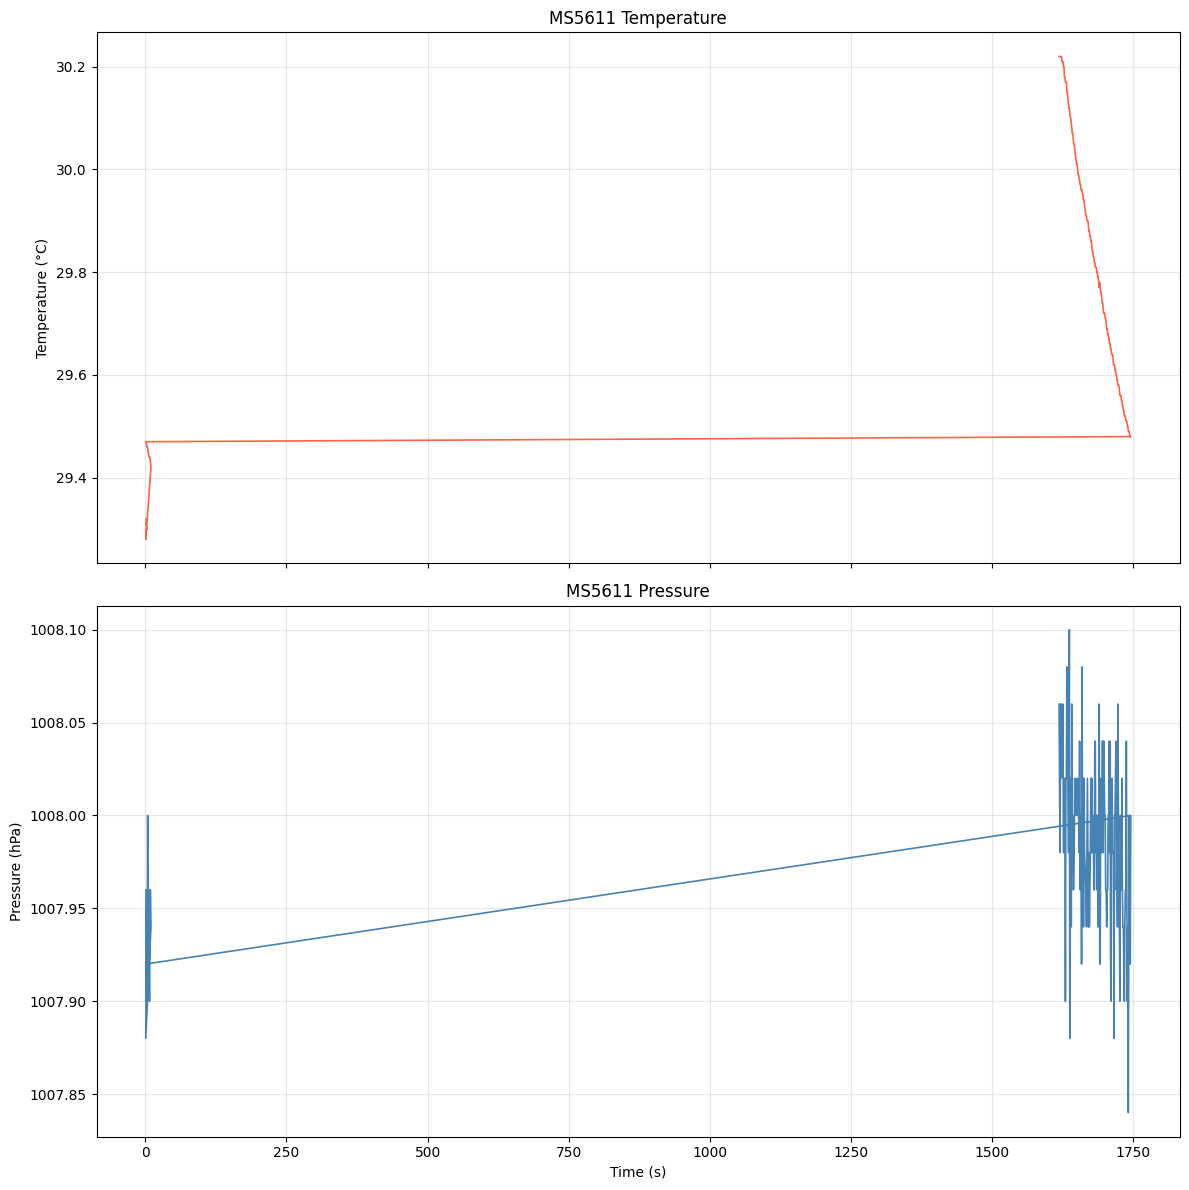

In [41]:
# Temperature & Pressure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)
ax1.plot(df.time_s, df.temp, color='tomato', linewidth=1.2)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('MS5611 Temperature')
ax1.grid(True, alpha=0.3)
ax2.plot(df.time_s, df.pressure, color='steelblue', linewidth=1.2)
ax2.set_ylabel('Pressure (hPa)')
ax2.set_xlabel('Time (s)')
ax2.set_title('MS5611 Pressure')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

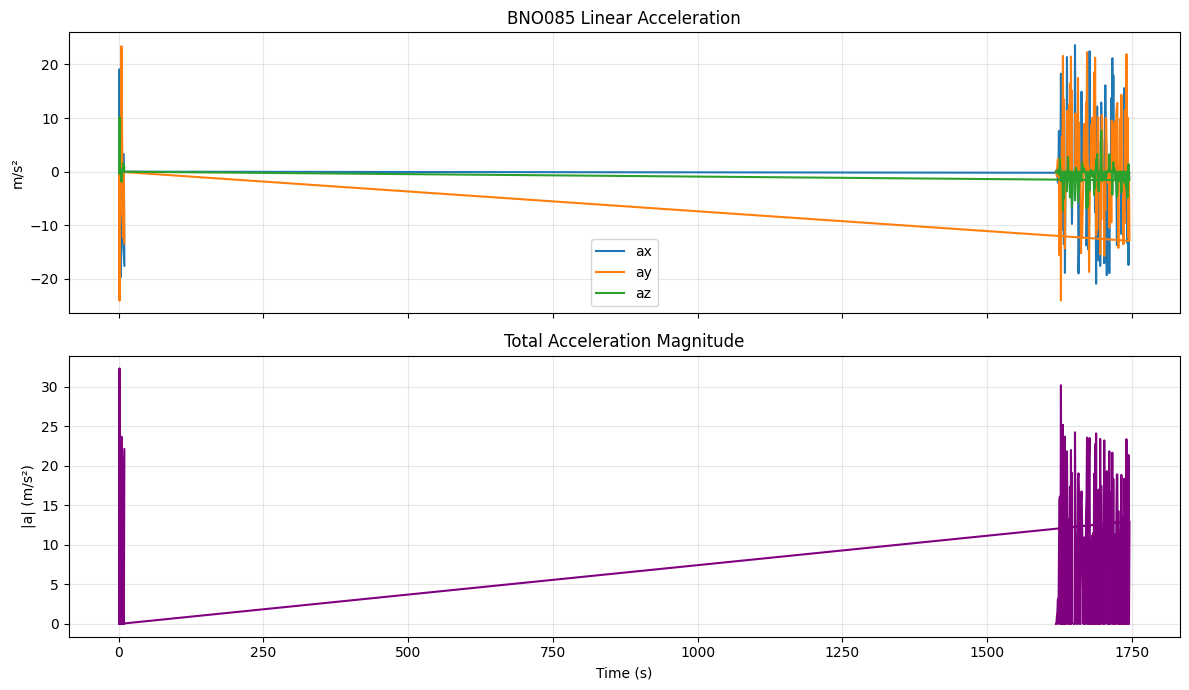

In [42]:
# BNO085 Linear Acceleration
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(df.time_s, df.ax, label='ax')
axes[0].plot(df.time_s, df.ay, label='ay')
axes[0].plot(df.time_s, df.az, label='az')
axes[0].set_ylabel('m/s²')
axes[0].set_title('BNO085 Linear Acceleration')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

df['accel_mag'] = np.sqrt(df.ax**2 + df.ay**2 + df.az**2)
axes[1].plot(df.time_s, df.accel_mag, color='purple')
axes[1].set_ylabel('|a| (m/s²)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Total Acceleration Magnitude')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

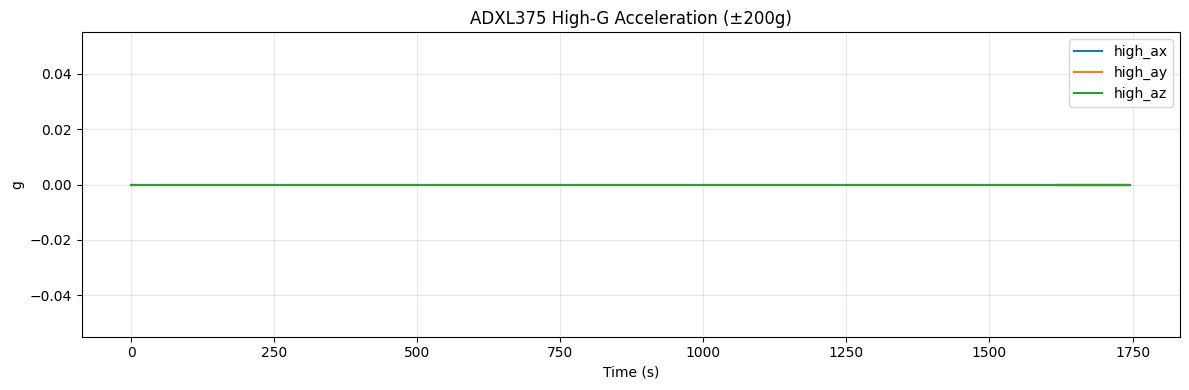

In [43]:
# ADXL375 High-G
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.time_s, df.high_ax, label='high_ax')
ax.plot(df.time_s, df.high_ay, label='high_ay')
ax.plot(df.time_s, df.high_az, label='high_az')
ax.set_xlabel('Time (s)')
ax.set_ylabel('g')
ax.set_title('ADXL375 High-G Acceleration (±200g)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

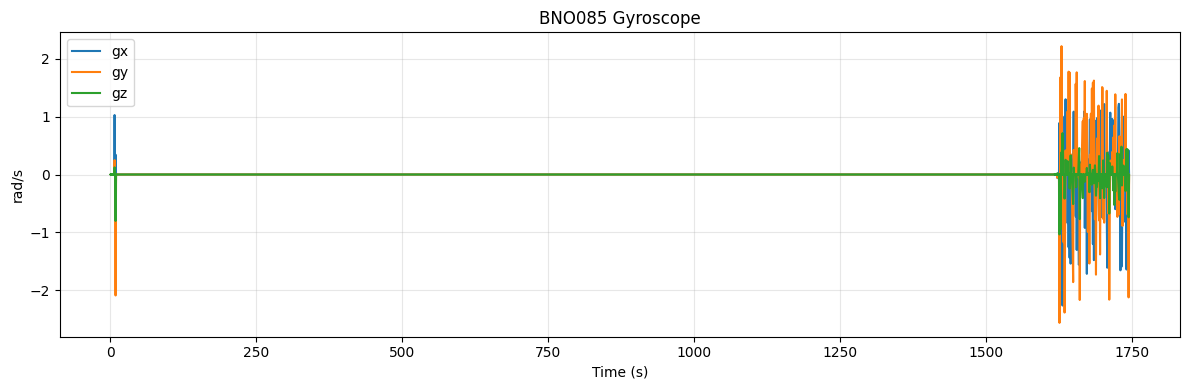

In [44]:
# BNO085 Gyroscope
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.time_s, df.gx, label='gx')
ax.plot(df.time_s, df.gy, label='gy')
ax.plot(df.time_s, df.gz, label='gz')
ax.set_xlabel('Time (s)')
ax.set_ylabel('rad/s')
ax.set_title('BNO085 Gyroscope')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

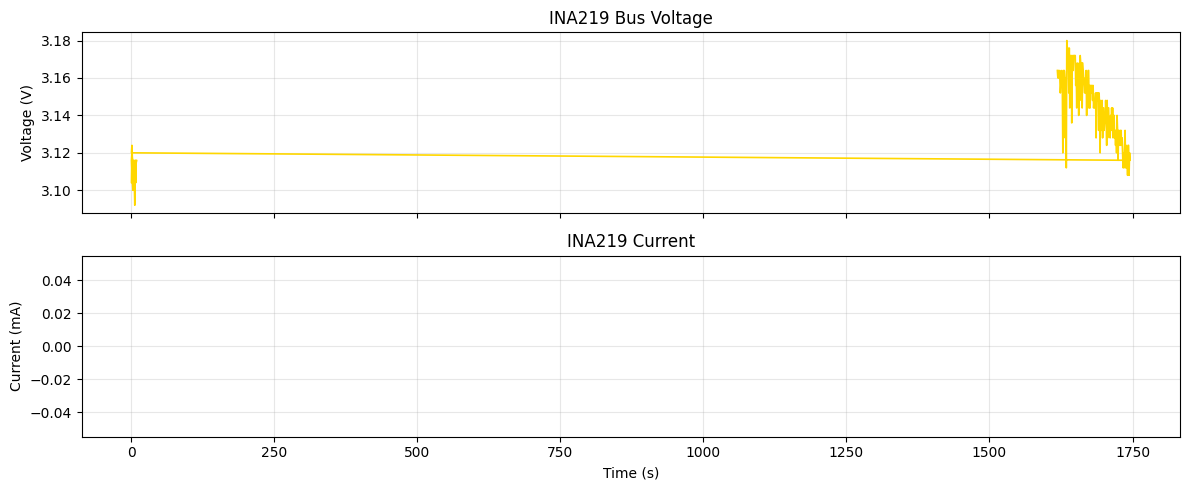

Avg voltage: 3.141 V
Avg current: nan mA
Avg power:   nan mW


In [45]:
# Power: Voltage & Current
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(df.time_s, df.voltage, color='gold', linewidth=1.2)
ax1.set_ylabel('Voltage (V)')
ax1.set_title('INA219 Bus Voltage')
ax1.grid(True, alpha=0.3)
ax2.plot(df.time_s, df.current, color='orange', linewidth=1.2)
ax2.set_ylabel('Current (mA)')
ax2.set_xlabel('Time (s)')
ax2.set_title('INA219 Current')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Avg voltage: {df.voltage.mean():.3f} V')
print(f'Avg current: {df.current.mean():.1f} mA')
print(f'Avg power:   {(df.voltage * df.current).mean():.1f} mW')

In [46]:
# GPS Track — Interactive Map (Mapbox)
import plotly.express as px

gps_valid = df[(df.sats > 0) & (df.lat != 0) & (df.lon != 0)]
if len(gps_valid) > 0:
    fig = px.scatter_mapbox(
        gps_valid,
        lat='lat',
        lon='lon',
        color='alt_gps',    
        size_max=10,
        zoom=14,
        height=600,
        color_continuous_scale='Viridis',
        labels={'alt_gps': 'Altitude (m)'},
        title=f'GPS Track ({len(gps_valid)} points)',
        mapbox_style="open-street-map"
    )
    fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
    fig.show()
else:
    print('No valid GPS fix in log.')

/tmp/ipykernel_32412/2791933470.py:6: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



Apogee (baro): 45.14 m at t=1741.3 s


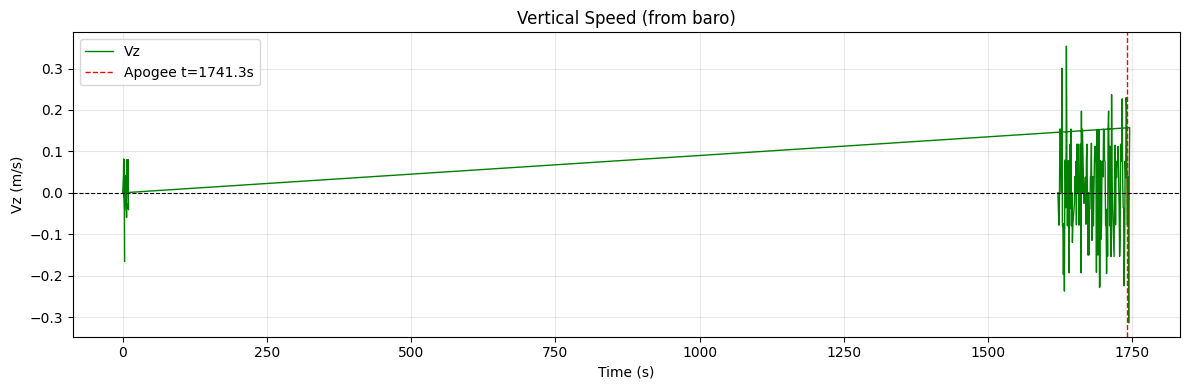

In [47]:
# Apogee detection + vertical speed
idx_apogee = df.alt_baro.idxmax()
apogee_alt = df.alt_baro[idx_apogee]
apogee_t   = df.time_s[idx_apogee]
print(f'Apogee (baro): {apogee_alt:.2f} m at t={apogee_t:.1f} s')

df['alt_smooth'] = df.alt_baro.rolling(5, center=True).mean()
df['vz'] = df.alt_smooth.diff() / df.time_s.diff()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.time_s, df.vz, color='green', linewidth=1.0, label='Vz')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(apogee_t, color='red', linewidth=1.0, linestyle='--', label=f'Apogee t={apogee_t:.1f}s')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Vz (m/s)')
ax.set_title('Vertical Speed (from baro)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# Export cleaned CSV
out_path = Path('log_clean.csv')
df.to_csv(out_path, index=False)
print(f'Saved {len(df)} rows to {out_path}')

Saved 160 rows to log_clean.csv
